<a href="https://colab.research.google.com/github/KarthikUppalapati57/Non-Human-Language-2/blob/main/NLP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# colab file(optional)
* created just for having all files in one place
* added multiple codes to manage our api limitation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hubert to python Prediction

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import HubertModel, Wav2Vec2FeatureExtractor
import librosa
from tqdm import tqdm
import json
import warnings
import time
import traceback

warnings.filterwarnings('ignore')

# 1. DEFINE THE MODEL
class MultiTaskHuBERT(nn.Module):
    """HuBERT with two classification heads"""
    def __init__(self, model_name, num_activity_labels, num_vocalization_labels):
        super().__init__()
        self.hubert = HubertModel.from_pretrained(model_name)
        hidden_size = self.hubert.config.hidden_size
        self.activity_classifier = nn.Linear(hidden_size, num_activity_labels)
        self.vocalization_classifier = nn.Linear(hidden_size, num_vocalization_labels)
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_values):
        outputs = self.hubert(input_values)
        hidden_states = outputs.last_hidden_state
        pooled = torch.mean(hidden_states, dim=1)
        pooled = self.dropout(pooled)
        activity_logits = self.activity_classifier(pooled)
        vocalization_logits = self.vocalization_classifier(pooled)
        return activity_logits, vocalization_logits

# 2. CONFIGURATION
class InferenceConfig:
    # Path to the ROOT folder containing your "Raw..." folders
    DATA_ROOT_DIR = r'/content/drive/MyDrive/Dolphin_project/Project/Data'

    # Path to the FOLDER containing the .pt and .json files (Models)
    MODEL_LOAD_DIR = r'/content/drive/MyDrive/Dolphin_project/Project/weighted_cross_outputs_3'

    # Path to the FOLDER where you want to save prediction_log.csv
    PREDICTION_SAVE_DIR = r'/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions'

    # Model and Audio settings
    MODEL_NAME = 'facebook/hubert-base-ls960'
    SAMPLE_RATE = 16000
    SEGMENT_LENGTH = 10.0
    WINDOW_STEP = 5.0

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_FOLDS = 5


# 3. HELPER FUNCTIONS (Loading & Prediction)
def load_models_and_labels(config):
    """
    Loads the models and label maps ONCE so we don't reload them for every file.
    """
    print(f"--- Initializing: Loading models from {config.MODEL_LOAD_DIR} ---")

    # 1. Load Label Mappings
    try:
        with open(os.path.join(config.MODEL_LOAD_DIR, 'activity_id2label.json'), 'r') as f:
            activity_id2label = {int(k): v for k, v in json.load(f).items()}
        with open(os.path.join(config.MODEL_LOAD_DIR, 'vocalization_id2label.json'), 'r') as f:
            vocalization_id2label = {int(k): v for k, v in json.load(f).items()}
    except FileNotFoundError:
        print(f"ERROR: Could not find label mapping files in {config.MODEL_LOAD_DIR}")
        return None, None, None, None

    num_activity_labels = len(activity_id2label)
    num_vocalization_labels = len(vocalization_id2label)

    # 2. Load Feature Extractor
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(config.MODEL_NAME)

    # 3. Load Models (Ensemble)
    models = []
    print(f"Loading {config.NUM_FOLDS} models for ensembling...")
    for fold in range(1, config.NUM_FOLDS + 1):
        model_path = os.path.join(config.MODEL_LOAD_DIR, f'multitask_fold{fold}_best.pt')
        if not os.path.exists(model_path):
            print(f"Warning: Model file not found, skipping: {model_path}")
            continue

        model = MultiTaskHuBERT(config.MODEL_NAME, num_activity_labels, num_vocalization_labels)
        model.load_state_dict(torch.load(model_path, map_location=config.DEVICE))
        model.eval()
        model.to(config.DEVICE)
        models.append(model)

    if not models:
        print("ERROR: No models loaded.")
        return None, None, None, None

    print(f"Successfully loaded {len(models)} models on {config.DEVICE}.")

    return models, feature_extractor, activity_id2label, vocalization_id2label


def predict_single_file(file_path, models, feature_extractor, activity_id2label, vocalization_id2label, config):
    """
    Runs prediction on a single audio file using pre-loaded models.
    """
    print(f"\nProcessing: {os.path.basename(file_path)}")

    # 1. Load Audio
    try:
        audio, sr = librosa.load(file_path, sr=config.SAMPLE_RATE)
    except Exception as e:
        print(f"ERROR loading file {file_path}: {e}")
        return

    target_length_samples = int(config.SEGMENT_LENGTH * config.SAMPLE_RATE)
    step_samples = int(config.WINDOW_STEP * config.SAMPLE_RATE)

    # Check if audio is shorter than one segment
    if len(audio) < target_length_samples:
        print(f"Skipping: Audio too short ({len(audio)/sr:.2f}s)")
        return

    num_segments = (len(audio) - target_length_samples) // step_samples + 1

    # 2. Inference Loop
    results = []
    for i in tqdm(range(num_segments), desc="Segments", leave=False):
        start = i * step_samples
        end = start + target_length_samples
        segment = audio[start:end]

        inputs = feature_extractor(
            segment,
            sampling_rate=config.SAMPLE_RATE,
            return_tensors="pt",
            padding=True
        )
        input_values = inputs.input_values.to(config.DEVICE)

        all_activity_probs = []
        all_vocalization_probs = []

        with torch.no_grad():
            for model in models:
                activity_logits, vocalization_logits = model(input_values)
                all_activity_probs.append(torch.nn.functional.softmax(activity_logits, dim=1))
                all_vocalization_probs.append(torch.nn.functional.softmax(vocalization_logits, dim=1))

        avg_activity_probs = torch.mean(torch.stack(all_activity_probs), dim=0)
        avg_vocalization_probs = torch.mean(torch.stack(all_vocalization_probs), dim=0)

        activity_pred_id = torch.argmax(avg_activity_probs, dim=1).item()
        vocalization_pred_id = torch.argmax(avg_vocalization_probs, dim=1).item()

        results.append({
            'filename': os.path.basename(file_path),
            'start_time_s': f"{start / config.SAMPLE_RATE:.1f}",
            'end_time_s': f"{end / config.SAMPLE_RATE:.1f}",
            'activity': activity_id2label[activity_pred_id],
            'activity_conf': f"{avg_activity_probs[0, activity_pred_id].item():.2f}",
            'vocalization': vocalization_id2label[vocalization_pred_id],
            'vocal_conf': f"{avg_vocalization_probs[0, vocalization_pred_id].item():.2f}"
        })

    # 3. Save Results
    if results:
        df = pd.DataFrame(results)
        os.makedirs(config.PREDICTION_SAVE_DIR, exist_ok=True)

        # Create a unique log file name based on the input filename
        test_file_name = os.path.basename(file_path)
        log_file_name = f"pred_{os.path.splitext(test_file_name)[0]}.csv"
        log_file_path = os.path.join(config.PREDICTION_SAVE_DIR, log_file_name)

        df.to_csv(log_file_path, index=False)
        print(f"Saved -> {log_file_path}")
    else:
        print("No results generated.")


# 4. MAIN LOOP (TRAVERSE FOLDERS)
def process_all_files(config):
    # 1. Load Resources ONCE
    models, extractor, act_map, voc_map = load_models_and_labels(config)

    if models is None:
        print("Initialization failed. Exiting.")
        return

    # 2. Walk through directory
    files_found_count = 0

    print(f"\n--- Scanning folders in {config.DATA_ROOT_DIR} ---")

    for root, dirs, files in os.walk(config.DATA_ROOT_DIR):
        # Get the name of the current folder
        folder_name = os.path.basename(root)

        # Check if folder starts with "Raw"
        if folder_name.startswith("Raw"):
            print(f"\nFound Target Folder: {folder_name}")

            for file in files:
                if file.lower().endswith('.wav'):
                    files_found_count += 1
                    full_path = os.path.join(root, file)

                    try:
                        predict_single_file(
                            full_path,
                            models,
                            extractor,
                            act_map,
                            voc_map,
                            config
                        )
                    except Exception as e:
                        print(f"CRITICAL ERROR processing {file}: {e}")
                        traceback.print_exc()
                        continue

    print(f"\n--- Processing Complete. Processed {files_found_count} files. ---")

if __name__ == '__main__':
    try:
        config = InferenceConfig()

        # Check if data dir exists
        if not os.path.exists(config.DATA_ROOT_DIR):
            print(f"Error: Data folder not found at {config.DATA_ROOT_DIR}")
        else:
            process_all_files(config)

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        traceback.print_exc()

--- Initializing: Loading models from /content/drive/MyDrive/Dolphin_project/Project/weighted_cross_outputs_3 ---


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

Loading 5 models for ensembling...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

Saved -> /content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions/pred_20211120_122623_192.csv

Processing: 20211120_125126_192.wav


Saved -> /content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions/pred_20211120_125126_192.csv

Processing: 20211120_124124_192.wav


Saved -> /content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions/pred_20211120_124124_192.csv

Processing: 20211120_123624_192.wav


Saved -> /content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions/pred_20211120_123624_192.csv

Processing: 20211120_124625_192.wav


Saved -> /content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions/pred_20211120_124625_192.csv

--- Processing Complete. Processed 287 files. ---


# Experiment-1

In [ ]:
!pip uninstall -y google-generativeai
!pip install -U google-generativeai

In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
from google.api_core import exceptions
from dotenv import load_dotenv
from google.colab import userdata


# --- 1. CONFIGURATION ---
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
REPORTS_SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-1_Gemini_Analysis_Reports"

# --- 2. SETUP GEMINI ---
def get_gemini_model():
    load_dotenv()
    api_key = userdata.get('GOOGLE_API_KEY')
    if not api_key:
        api_key = input("Paste API Key: ").strip()
    genai.configure(api_key=api_key)

    # We prefer 1.5 Flash for batch tasks (often more stable limits)
    models = ['gemini-1.5-flash', 'gemini-1.5-flash-001', 'gemini-2.0-flash']

    for m in models:
        try:
            model = genai.GenerativeModel(m)
            model.generate_content("Ping")
            print(f" Connected using: {m}")
            return model
        except:
            continue
    raise ValueError("Could not connect to Gemini.")

# --- 3. HELPER: DATA LOADER ---
def get_data(path):
    try:
        df = pd.read_csv(path)
        act = df['activity'].value_counts(normalize=True).round(3).to_dict() if 'activity' in df else {}
        voc = df['vocalization'].value_counts(normalize=True).round(3).to_dict() if 'vocalization' in df else {}
        return act, voc
    except:
        return None, None

# --- 4. MAIN LOOP WITH INTELLIGENT RETRY ---
def run():
    print("\n=== Gemini Batch Processor (Slow & Steady Mode) ===\n")

    # Setup
    if not os.path.exists(REPORTS_SAVE_DIR): os.makedirs(REPORTS_SAVE_DIR)
    model = get_gemini_model()

    # Get Files
    all_files = [f for f in os.listdir(PREDICTIONS_DIR) if f.endswith(".csv") and "pred" in f]
    total_files = len(all_files)
    print(f"Found {total_files} logs. Starting processing...")

    for i, filename in enumerate(all_files):
        session_id = filename.replace("prediction_log_", "").replace("pred_", "").replace(".csv", "")
        save_path = os.path.join(REPORTS_SAVE_DIR, f"report_{session_id}.txt")

        # 1. SKIP IF DONE
        if os.path.exists(save_path):
            print(f"[{i+1}/{total_files}] Skipping {session_id} (Already exists)")
            continue

        # 2. LOAD DATA
        act, voc = get_data(os.path.join(PREDICTIONS_DIR, filename))
        if not act:
            print(f"[{i+1}/{total_files}] Skipping {session_id} (Data Error)")
            continue

        # 3. GENERATE (With Infinite Retry Loop)
        print(f"[{i+1}/{total_files}] Processing {session_id}...", end="", flush=True)

        prompt = f"""
        Role: Marine Biologist.
        Task: Analyze dolphin behavior for Session {session_id}.
        Stats: Activity={act}, Vocalization={voc}.
        Definitions: FFR(Feeding), ORD(Training), PLAY(Playing), NIGHT(Sleep).
        Output: 3 sentences on dominant behavior and social context.
        """

        while True:
            try:
                response = model.generate_content(prompt)

                # Save
                with open(save_path, "w", encoding="utf-8") as f:
                    f.write(response.text)

                print(" DONE.")
                time.sleep(5)
                break

            except exceptions.ResourceExhausted:
                print("\n SPEED LIMIT HIT (429). Pausing for 60 seconds...", end="", flush=True)
                time.sleep(60)
                print(" Retrying...", end="", flush=True)
            except Exception as e:
                print(f"\n  Error: {e}")
                break

if __name__ == "__main__":
    run()


=== Gemini Batch Processor (Slow & Steady Mode) ===



 Connected using: gemini-2.0-flash
Found 287 logs. Starting processing...
[1/287] Skipping 20211121_084845_192 (Already exists)
[2/287] Skipping 20211121_085346_192 (Already exists)
[3/287] Skipping 20211121_090347_192 (Already exists)
[4/287] Skipping 20211121_085846_192 (Already exists)
[5/287] Skipping 20211121_093603_192 (Already exists)
[6/287] Skipping 20211121_091849_192 (Already exists)
[7/287] Skipping 20211121_091348_192 (Already exists)
[8/287] Skipping 20211121_093102_192 (Already exists)
[9/287] Skipping 20211121_092349_192 (Already exists)
[10/287] Skipping 20211121_092850_192 (Already exists)
[11/287] Skipping 20211121_090848_192 (Already exists)
[12/287] Skipping 20211121_095105_192 (Already exists)
[13/287] Skipping 20211121_100607_192 (Already exists)
[14/287] Skipping 20211121_100106_192 (Already exists)
[15/287] Skipping 20211121_094104_192 (Already exists)
[16/287] Processing 20211121_094604_192... DONE.
[17/287] Processing 20211121_095606_192... DONE.
[18/287] Pro


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 30.463852427s.
[161/287] Processing 20211120_182704_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 30.299817691s.
[162/287] Processing 20211120_182204_192... DONE.
[163/287] Processing 20211120_185207_192... DONE.
[164/287] Processing 20211120_185708_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 17.682081662s.
[165/287] Processing 20211120_190208_192...

...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 38.064686524s.
[284/287] Processing 20211120_125126_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 37.879893566s.
[285/287] Processing 20211120_124124_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 37.722174878s.
[286/287] Processing 20211120_123624_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 37.527824804s.
[287/287] Processing 20211120_124625_192...


  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 37.366528183s.


In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
from google.api_core import exceptions
from dotenv import load_dotenv
from google.colab import userdata


# --- 1. CONFIGURATION ---
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
REPORTS_SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-1_Gemini_Analysis_Reports"

# --- 2. SMART MODEL SELECTOR ---
def get_best_available_model():
    load_dotenv()
    api_key = userdata.get('GOOGLE_API_KEY_1')
    if not api_key:
        api_key = input("Paste API Key: ").strip()
    genai.configure(api_key=api_key)

    print(" Scanning your available models...")
    try:
        # 1. Get list of ALL models your key can access
        my_models = []
        for m in genai.list_models():
            if 'generateContent' in m.supported_generation_methods:
                my_models.append(m.name)

        print(f"   Found: {my_models}")

        # 2. Pick the best one (Priority: 1.5 Flash > 1.5 Pro > 1.0 Pro)
        # We avoid 'exp' (experimental) models if possible because they have low limits
        selected_model = None

        # Priority list (partial matches)
        priorities = ['gemini-1.5-flash', 'gemini-1.5-pro', 'gemini-pro']

        for p in priorities:
            for m in my_models:
                if p in m and 'exp' not in m: # Prefer stable versions
                    selected_model = m
                    break
            if selected_model: break

        # Fallback to anything if no preference found
        if not selected_model and my_models:
            selected_model = my_models[0]

        if not selected_model:
            raise ValueError("No models found!")

        print(f" Auto-Selected Model: {selected_model}")
        return genai.GenerativeModel(selected_model)

    except Exception as e:
        print(f" Error listing models: {e}")
        print("   -> Forcing fallback to 'models/gemini-1.5-flash'...")
        return genai.GenerativeModel('models/gemini-1.5-flash')

# 3. HELPER: DATA LOADER ---
def get_data(path):
    try:
        df = pd.read_csv(path)
        act = df['activity'].value_counts(normalize=True).round(3).to_dict() if 'activity' in df else {}
        voc = df['vocalization'].value_counts(normalize=True).round(3).to_dict() if 'vocalization' in df else {}
        return act, voc
    except:
        return None, None

# 4. MAIN LOOP ---
def run():
    print("\n=== Completing Missing Files (Auto-Detect Mode) ===\n")

    if not os.path.exists(REPORTS_SAVE_DIR): os.makedirs(REPORTS_SAVE_DIR)

    try:
        model = get_best_available_model()
    except Exception as e:
        print(f"Critical Setup Error: {e}")
        return

    # Get Files
    all_files = [f for f in os.listdir(PREDICTIONS_DIR) if f.endswith(".csv") and "pred" in f]
    total_files = len(all_files)

    # Check progress
    done_count = len(os.listdir(REPORTS_SAVE_DIR))
    print(f"\nTotal Logs: {total_files}")
    print(f"Already Done: {done_count}")
    print(f"Remaining:  {total_files - done_count}")
    print("-" * 30)

    for i, filename in enumerate(all_files):
        session_id = filename.replace("prediction_log_", "").replace("pred_", "").replace(".csv", "")
        save_path = os.path.join(REPORTS_SAVE_DIR, f"report_{session_id}.txt")

        # SKIP IF DONE
        if os.path.exists(save_path):
            continue

        # LOAD DATA
        act, voc = get_data(os.path.join(PREDICTIONS_DIR, filename))
        if not act:
            print(f"Skipping {session_id} (Data Empty)")
            continue

        print(f"[{i+1}/{total_files}] Processing {session_id}...", end="", flush=True)

        prompt = f"""
        Role: Marine Biologist.
        Task: Analyze dolphin behavior for Session {session_id}.
        Stats: Activity={act}, Vocalization={voc}.
        Definitions: FFR(Feeding), ORD(Training), PLAY(Playing), NIGHT(Sleep).
        Output: 3 sentences on dominant behavior and social context.
        """

        # Retry Logic
        retries = 3
        while retries > 0:
            try:
                response = model.generate_content(prompt)

                with open(save_path, "w", encoding="utf-8") as f:
                    f.write(response.text)

                print(" DONE.")
                time.sleep(5) # Wait 5s to be safe
                break

            except Exception as e:
                error_str = str(e)
                if "429" in error_str or "Quota" in error_str:
                    print(f"\n Limit Hit. Pausing 60s...", end="", flush=True)
                    time.sleep(60)
                    print(" Retrying...", end="", flush=True)
                else:
                    print(f" Error: {e}")
                    retries -= 1
                    time.sleep(5)

if __name__ == "__main__":
    run()


=== Completing Missing Files (Auto-Detect Mode) ===

 Scanning your available models...
   Found: ['models/gemini-2.5-pro-preview-03-25', 'models/gemini-2.5-flash', 'models/gemini-2.5-pro-preview-05-06', 'models/gemini-2.5-pro-preview-06-05', 'models/gemini-2.5-pro', 'models/gemini-2.0-flash-exp', 'models/gemini-2.0-flash', 'models/gemini-2.0-flash-001', 'models/gemini-2.0-flash-exp-image-generation', 'models/gemini-2.0-flash-lite-001', 'models/gemini-2.0-flash-lite', 'models/gemini-2.0-flash-lite-preview-02-05', 'models/gemini-2.0-flash-lite-preview', 'models/gemini-2.0-pro-exp', 'models/gemini-2.0-pro-exp-02-05', 'models/gemini-exp-1206', 'models/gemini-2.0-flash-thinking-exp-01-21', 'models/gemini-2.0-flash-thinking-exp', 'models/gemini-2.0-flash-thinking-exp-1219', 'models/gemini-2.5-flash-preview-tts', 'models/gemini-2.5-pro-preview-tts', 'models/learnlm-2.0-flash-experimental', 'models/gemma-3-1b-it', 'models/gemma-3-4b-it', 'models/gemma-3-12b-it', 'models/gemma-3-27b-it', 'mod


 Limit Hit. Pausing 60s... Retrying... DONE.
[245/287] Processing 20211120_215729_192... DONE.
[246/287] Processing 20211120_221732_192... DONE.
[248/287] Processing 20211120_222733_192... DONE.
[249/287] Processing 20211120_222232_192... DONE.
[250/287] Processing 20211120_220230_192... DONE.
[251/287] Processing 20211120_221231_192... DONE.
[252/287] Processing 20211120_223234_192... DONE.
[253/287] Processing 20211120_223734_192... DONE.
[254/287] Processing 20211120_224235_192... DONE.
[255/287] Processing 20211120_225236_192... DONE.
[256/287] Processing 20211120_224735_192...


 Limit Hit. Pausing 60s... Retrying... DONE.
[257/287] Processing 20211120_102609_192... DONE.
[260/287] Processing 20211120_104111_192... DONE.
[261/287] Processing 20211120_104611_192... DONE.
[262/287] Processing 20211120_105613_192... DONE.
[263/287] Processing 20211120_103610_192... DONE.
[264/287] Processing 20211120_110113_192... DONE.
[265/287] Processing 20211120_105112_192... DONE.
[266/287] Processing 20211120_111615_192... DONE.
[267/287] Processing 20211120_112115_192... DONE.
[268/287] Processing 20211120_110614_192... DONE.
[269/287] Processing 20211120_113116_192... DONE.
[270/287] Processing 20211120_112616_192... DONE.
[271/287] Processing 20211120_111114_192... DONE.
[272/287] Processing 20211120_113617_192...


 Limit Hit. Pausing 60s... Retrying... DONE.
[273/287] Processing 20211120_115119_192... DONE.
[275/287] Processing 20211120_115619_192... DONE.
[276/287] Processing 20211120_114118_192... DONE.
[277/287] Processing 20211120_114618_192... DONE.
[278/287] Processing 20211120_120620_192... DONE.
[280/287] Processing 20211120_121622_192... DONE.
[281/287] Processing 20211120_123123_192...
 Limit Hit. Pausing 60s...

 Retrying... DONE.
[282/287] Processing 20211120_121121_192... DONE.
[283/287] Processing 20211120_122623_192... DONE.
[284/287] Processing 20211120_125126_192... DONE.
[285/287] Processing 20211120_124124_192... DONE.
[286/287] Processing 20211120_123624_192... DONE.
[287/287] Processing 20211120_124625_192... DONE.


# Experiment-2

In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
import importlib
from google.api_core import exceptions
from dotenv import load_dotenv

# 1. CONFIGURATION
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
REPORTS_SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-2_Gemini_Analysis_Reports"

# 2. THE UNIVERSAL CONNECTOR (Brute Force Discovery)
def find_working_flash_model():
    load_dotenv()
    api_key = os.getenv("GOOGLE_API_KEY_2")

    # Safe Colab Import
    if not api_key:
        try:
            if importlib.util.find_spec("google.colab") is not None:
                from google.colab import userdata
                api_key = userdata.get('GOOGLE_API_KEY_2')
        except: pass

    if not api_key:
        api_key = input("Paste API Key: ").strip()

    genai.configure(api_key=api_key)

    # LIST OF CANDIDATES (Priority: High Speed -> Stable -> Backup)
    candidates = [
        'gemini-2.0-flash',
        'gemini-1.5-flash',
        'gemini-1.5-flash-001',
        'gemini-1.5-flash-002',
        'gemini-1.5-flash-latest',
        'gemini-1.5-flash-8b',
        'models/gemini-1.5-flash'
    ]

    print("\n Testing connection to High-Speed models ")

    for model_name in candidates:
        print(f"    Trying '{model_name}'...", end=" ")
        try:
            model = genai.GenerativeModel(model_name)
            # We must generate content to prove it actually works (not just loads)
            model.generate_content("Ping")
            print(" SUCCESS!")
            return model
        except Exception as e:
            error_msg = str(e)
            if "404" in error_msg:
                print(" Not Found (404)")
            elif "429" in error_msg:
                print(" Quota Full (But model exists!)")
            else:
                print(f" Error: {error_msg[:50]}...")
            continue

    print("\n CRITICAL: No Flash models worked. Trying 'Gemini Pro' as last resort...")
    # Last resort: Pro model (Slow, low quota, but usually exists)
    return genai.GenerativeModel('gemini-pro')

# 3. DATA LOADER
def get_data(path):
    try:
        df = pd.read_csv(path)
        act = df['activity'].value_counts(normalize=True).round(3).to_dict() if 'activity' in df else {}
        voc = df['vocalization'].value_counts(normalize=True).round(3).to_dict() if 'vocalization' in df else {}
        return act, voc
    except: return None, None

# 4. MAIN LOOP (RESUMABLE)
def run():
    print("\n=== Experiment 2: Auto-Healing Batch Analysis ===\n")

    if not os.path.exists(REPORTS_SAVE_DIR): os.makedirs(REPORTS_SAVE_DIR)

    # 1. Find a working model
    try:
        model = find_working_flash_model()
    except Exception as e:
        print(f"Setup Failed: {e}")
        return

    # 2. Get Files
    all_files = [f for f in os.listdir(PREDICTIONS_DIR) if f.endswith(".csv") and "pred" in f]
    total_files = len(all_files)
    done_count = len(os.listdir(REPORTS_SAVE_DIR))

    print(f"\n Progress: {done_count}/{total_files} Completed. Resuming...")
    print("-" * 50)

    for i, filename in enumerate(all_files):
        session_id = filename.replace("prediction_log_", "").replace("pred_", "").replace(".csv", "")
        save_path = os.path.join(REPORTS_SAVE_DIR, f"report_{session_id}.txt")

        # SKIP COMPLETED
        if os.path.exists(save_path):
            continue

        # DATA CHECK
        act, voc = get_data(os.path.join(PREDICTIONS_DIR, filename))
        if not act:
            print(f"Skipping {session_id} (Empty File)")
            continue

        print(f"[{i+1}/{total_files}] Analyzing {session_id}...", end="", flush=True)

        # PROMPT
        prompt = f"""
        Role: Expert Marine Biologist.
        Task: Interpret the behavioral profile of a dolphin recording session.

        [TEACHING EXAMPLES]
        Example 1 (Clear Activity):
        Input: {{'PLAY': 0.85, 'unknown': 0.15}}, {{'W': 0.90, 'NOISE': 0.10}}
        Output: This session is clearly dominated by Play behavior (85%). The strong presence of Whistles ('W' at 90%) confirms this is a social, non-aggressive interaction.

        [CURRENT DATA: {session_id}]
        - Activity: {act}
        - Vocalization: {voc}

        [YOUR ANALYSIS]
        Synthesize this data. What is the dolphin doing?
        """

        # RETRY LOOP
        while True:
            try:
                response = model.generate_content(prompt)
                with open(save_path, "w", encoding="utf-8") as f:
                    f.write(response.text)
                print(" DONE.")
                time.sleep(4.0)
                break

            except Exception as e:
                if "429" in str(e) or "Quota" in str(e):
                    print(f"\n     Speed Limit Hit. Waiting 60s...", end="", flush=True)
                    time.sleep(60)
                    print(" Retrying...", end="", flush=True)
                else:
                    print(f" Error: {e}")
                    break

if __name__ == "__main__":
    run()


=== Experiment 2: Auto-Healing Batch Analysis ===


 Testing connection to High-Speed models 
    Trying 'gemini-2.0-flash'...  SUCCESS!

 Progress: 0/287 Completed. Resuming...
--------------------------------------------------
[1/287] Analyzing 20211121_084845_192... DONE.
[2/287] Analyzing 20211121_085346_192... DONE.
[3/287] Analyzing 20211121_090347_192... DONE.
[4/287] Analyzing 20211121_085846_192... DONE.
[5/287] Analyzing 20211121_093603_192... DONE.
[6/287] Analyzing 20211121_091849_192... DONE.
[7/287] Analyzing 20211121_091348_192... DONE.
[8/287] Analyzing 20211121_093102_192... DONE.
[9/287] Analyzing 20211121_092349_192... DONE.
[10/287] Analyzing 20211121_092850_192... DONE.
[11/287] Analyzing 20211121_090848_192... DONE.
[12/287] Analyzing 20211121_095105_192... DONE.
[13/287] Analyzing 20211121_100607_192... DONE.
[14/287] Analyzing 20211121_100106_192... DONE.
[15/287] Analyzing 20211121_094104_192... DONE.
[16/287] Analyzing 20211121_094604_192... DONE.
[17/287] An


     Speed Limit Hit. Waiting 60s... Retrying...


     Speed Limit Hit. Waiting 60s... Retrying... DONE.
[200/287] Analyzing 20211120_164152_192... DONE.
[201/287] Analyzing 20211120_164653_192... DONE.
[202/287] Analyzing 20211120_165153_192...


     Speed Limit Hit. Waiting 60s... Retrying... DONE.
[203/287] Analyzing 20211120_172157_192... DONE.
[204/287] Analyzing 20211120_171155_192...


     Speed Limit Hit. Waiting 60s... Retrying... DONE.
[205/287] Analyzing 20211120_170655_192...

...


     Speed Limit Hit. Waiting 60s... Retrying...


     Speed Limit Hit. Waiting 60s... Retrying...


     Speed Limit Hit. Waiting 60s... Retrying...


     Speed Limit Hit. Waiting 60s...

KeyboardInterrupt: 

In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
import importlib
from google.api_core import exceptions
from dotenv import load_dotenv

# 1. CONFIGURATION
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
REPORTS_SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-2_Gemini_Analysis_Reports"

# 2. THE UNIVERSAL CONNECTOR (Brute Force Discovery)
def find_working_flash_model():
    load_dotenv()
    api_key = os.getenv("GOOGLE_API_KEY_3")

    # Safe Colab Import
    if not api_key:
        try:
            if importlib.util.find_spec("google.colab") is not None:
                from google.colab import userdata
                api_key = userdata.get('GOOGLE_API_KEY_3')
        except: pass

    if not api_key:
        api_key = input("Paste API Key: ").strip()

    genai.configure(api_key=api_key)

    # LIST OF CANDIDATES (Priority: High Speed -> Stable -> Backup)
    candidates = [
        'gemini-2.0-flash',
        'gemini-1.5-flash',
        'gemini-1.5-flash-001',
        'gemini-1.5-flash-002',
        'gemini-1.5-flash-latest',
        'gemini-1.5-flash-8b',
        'models/gemini-1.5-flash'
    ]

    print("\n Testing connection to High-Speed models ")

    for model_name in candidates:
        print(f"    Trying '{model_name}'...", end=" ")
        try:
            model = genai.GenerativeModel(model_name)
            # We must generate content to prove it actually works (not just loads)
            model.generate_content("Ping")
            print(" SUCCESS!")
            return model
        except Exception as e:
            error_msg = str(e)
            if "404" in error_msg:
                print(" Not Found (404)")
            elif "429" in error_msg:
                print(" Quota Full (But model exists!)")
            else:
                print(f" Error: {error_msg[:50]}...")
            continue

    print("\n CRITICAL: No Flash models worked. Trying 'Gemini Pro' as last resort...")
    # Last resort: Pro model (Slow, low quota, but usually exists)
    return genai.GenerativeModel('gemini-pro')

# 3. DATA LOADER
def get_data(path):
    try:
        df = pd.read_csv(path)
        act = df['activity'].value_counts(normalize=True).round(3).to_dict() if 'activity' in df else {}
        voc = df['vocalization'].value_counts(normalize=True).round(3).to_dict() if 'vocalization' in df else {}
        return act, voc
    except: return None, None

# 4. MAIN LOOP (RESUMABLE)
def run():
    print("\n Experiment 2: Auto-Healing Batch Analysis\n")

    if not os.path.exists(REPORTS_SAVE_DIR): os.makedirs(REPORTS_SAVE_DIR)

    # 1. Find a working model
    try:
        model = find_working_flash_model()
    except Exception as e:
        print(f"Setup Failed: {e}")
        return

    # 2. Get Files
    all_files = [f for f in os.listdir(PREDICTIONS_DIR) if f.endswith(".csv") and "pred" in f]
    total_files = len(all_files)
    done_count = len(os.listdir(REPORTS_SAVE_DIR))

    print(f"\n Progress: {done_count}/{total_files} Completed. Resuming...")
    print("-" * 50)

    for i, filename in enumerate(all_files):
        session_id = filename.replace("prediction_log_", "").replace("pred_", "").replace(".csv", "")
        save_path = os.path.join(REPORTS_SAVE_DIR, f"report_{session_id}.txt")

        # SKIP COMPLETED
        if os.path.exists(save_path):
            continue

        # DATA CHECK
        act, voc = get_data(os.path.join(PREDICTIONS_DIR, filename))
        if not act:
            print(f"Skipping {session_id} (Empty File)")
            continue

        print(f"[{i+1}/{total_files}] Analyzing {session_id}...", end="", flush=True)

        # PROMPT
        prompt = f"""
        Role: Expert Marine Biologist.
        Task: Interpret the behavioral profile of a dolphin recording session.

        [TEACHING EXAMPLES]
        Example 1 (Clear Activity):
        Input: {{'PLAY': 0.85, 'unknown': 0.15}}, {{'W': 0.90, 'NOISE': 0.10}}
        Output: This session is clearly dominated by Play behavior (85%). The strong presence of Whistles ('W' at 90%) confirms this is a social, non-aggressive interaction.

        [CURRENT DATA: {session_id}]
        - Activity: {act}
        - Vocalization: {voc}

        [YOUR ANALYSIS]
        Synthesize this data. What is the dolphin doing?
        """

        # RETRY LOOP
        while True:
            try:
                response = model.generate_content(prompt)
                with open(save_path, "w", encoding="utf-8") as f:
                    f.write(response.text)
                print(" DONE.")
                time.sleep(4.0)
                break

            except Exception as e:
                if "429" in str(e) or "Quota" in str(e):
                    print(f"\n     Speed Limit Hit. Waiting 60s...", end="", flush=True)
                    time.sleep(60)
                    print(" Retrying...", end="", flush=True)
                else:
                    print(f" Error: {e}")
                    break

if __name__ == "__main__":
    run()


 Experiment 2: Auto-Healing Batch Analysis


 Testing connection to High-Speed models 
    Trying 'gemini-2.0-flash'...  SUCCESS!

 Progress: 205/287 Completed. Resuming...
--------------------------------------------------
[206/287] Analyzing 20211120_171656_192... DONE.
[207/287] Analyzing 20211120_170154_192... DONE.
[208/287] Analyzing 20211120_175200_192... DONE.
[209/287] Analyzing 20211120_174700_192... DONE.
[210/287] Analyzing 20211120_174159_192... DONE.
[211/287] Analyzing 20211120_172657_192... DONE.
[212/287] Analyzing 20211120_173158_192... DONE.
[213/287] Analyzing 20211120_173658_192... DONE.
[214/287] Analyzing 20211120_142636_192... DONE.
[215/287] Analyzing 20211120_141635_192... DONE.
[216/287] Analyzing 20211120_142136_192... DONE.
[217/287] Analyzing 20211120_141135_192... DONE.
[218/287] Analyzing 20211120_144639_192... DONE.
[219/287] Analyzing 20211120_143637_192... DONE.
[220/287] Analyzing 20211120_145139_192... DONE.
[221/287] Analyzing 20211120_144138_192.

# Experiment-3

In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
import importlib
from google.api_core import exceptions
from dotenv import load_dotenv
from google.colab import userdata

# CONFIGURATION
AUDIO_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Data"
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-3_Gemini_Audio_Comparisons"

# GEMINI SETUP FUNCTION
def get_gemini_model(primary_model='gemini-2.0-flash', fallback_model='gemini-1.5-flash'):
    load_dotenv()
    api_key = os.getenv("GOOGLE_API_KEY-4")

    if not api_key:
        try:
            if importlib.util.find_spec("google.colab") is not None:
                from google.colab import userdata
                api_key = userdata.get('GOOGLE_API_KEY-4')
        except: pass

    if not api_key:
        api_key = input("Paste API Key: ").strip()

    genai.configure(api_key=api_key)

    # Try to find a working flash model
    candidates = [
        'gemini-1.5-flash', 'gemini-1.5-flash-001', 'gemini-1.5-flash-002',
        'gemini-2.0-flash', 'gemini-pro'
    ]
    print(f" Connecting to AI...")
    for model_name in candidates:
        try:
            model = genai.GenerativeModel(model_name)
            model.generate_content("Ping")
            print(f"  Success! Using {model_name}")
            return model
        except:
            continue

    raise ValueError("CRITICAL: No working Gemini models found.")

def get_hubert_opinion(log_path):
    try:
        df = pd.read_csv(log_path)
        if 'activity' in df.columns:
            k = df[df['activity'] != 'unknown']['activity']
            act = k.mode()[0] if not k.empty else df['activity'].mode()[0]
        else: act = "Error"
        if 'vocalization' in df.columns:
            voc = df['vocalization'].mode()[0]
        else: voc = "Error"
        return act, voc
    except: return None, None

def run():
    print("\n Experiment 3 \n")
    if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

    try:
        model = get_gemini_model()
    except Exception as e:
        print(f"Setup Error: {e}")
        return

    # Gather Files
    print(f"Scanning {AUDIO_DIR}...")
    audio_files = []
    for root, dirs, files in os.walk(AUDIO_DIR):
        for file in files:
            if file.lower().endswith(".wav"):
                audio_files.append(os.path.join(root, file))

    total = len(audio_files)
    print(f"Found {total} audio files.\n")

    # Loop
    for i, full_audio_path in enumerate(audio_files):
        filename = os.path.basename(full_audio_path)
        file_id = os.path.splitext(filename)[0]
        report_path = os.path.join(SAVE_DIR, f"comparison_{file_id}.txt")

        # SKIP IF EXISTS
        if os.path.exists(report_path):
            continue

        # FIND LOG
        log_path = os.path.join(PREDICTIONS_DIR, f"pred_{file_id}.csv")
        if not os.path.exists(log_path):
            # Try alternate naming
            log_path = os.path.join(PREDICTIONS_DIR, f"prediction_log_{file_id}.csv")
            if not os.path.exists(log_path):
                # print(f"Skipping {file_id} (No Log)")
                continue

        h_act, h_voc = get_hubert_opinion(log_path)
        if not h_act: continue

        print(f"[{i+1}/{total}] Processing {filename}...", end="", flush=True)

        # RETRY LOOP (Handles Connection Drops)
        max_retries = 3
        for attempt in range(max_retries):
            uploaded_file = None
            try:
                # 1. Upload
                uploaded_file = genai.upload_file(full_audio_path)
                while uploaded_file.state.name == "PROCESSING":
                    time.sleep(1)
                    uploaded_file = genai.get_file(uploaded_file.name)

                # 2. Prompt
                prompt = f"""
                Role: Expert Marine Biologist.
                Task: Validate Acoustic Model (HuBERT) vs Audio Reality.
                Prediction: Activity={h_act}, Vocalization={h_voc}.
                Definitions: FFR(Feeding), ORD(Training), PLAY(Playing), NIGHT(Sleep).
                Action: Listen to the audio. Do you agree with '{h_act}'? detailed verdict.
                """

                # 3. Generate
                response = model.generate_content([prompt, uploaded_file])

                # 4. SAVE IMMEDIATELY
                with open(report_path, "w", encoding="utf-8") as f:
                    f.write(f"File: {filename}\n")
                    f.write(f"HuBERT: {h_act} | {h_voc}\n")
                    f.write("-" * 30 + "\n")
                    f.write(response.text)

                print(" SAVED.")

                # Cleanup
                uploaded_file.delete()
                time.sleep(4)
                break

            except Exception as e:
                print(f"\n   Error (Attempt {attempt+1}): {e}")
                if uploaded_file:
                    try: uploaded_file.delete()
                    except: pass

                if "429" in str(e) or "Quota" in str(e):
                    print("    (Quota Hit. Waiting 60s)")
                    time.sleep(60)
                else:
                    print("    (Connection glitch. Retrying in 10s)")
                    time.sleep(10)

if __name__ == "__main__":
    run()


 Experiment 3 



 Connecting to AI...


  Success! Using gemini-2.0-flash
Scanning /content/drive/MyDrive/Dolphin_project/Project/Data...
Found 287 audio files.

[2/287] Processing 20211121_085346_192.wav... SAVED.
[3/287] Processing 20211121_090347_192.wav... SAVED.
[4/287] Processing 20211121_085846_192.wav... SAVED.
[5/287] Processing 20211121_093603_192.wav... SAVED.
[6/287] Processing 20211121_091849_192.wav... SAVED.
[7/287] Processing 20211121_091348_192.wav... SAVED.
[8/287] Processing 20211121_093102_192.wav... SAVED.
[9/287] Processing 20211121_092349_192.wav... SAVED.
[10/287] Processing 20211121_092850_192.wav... SAVED.
[11/287] Processing 20211121_090848_192.wav... SAVED.
[12/287] Processing 20211121_095105_192.wav... SAVED.
[13/287] Processing 20211121_100607_192.wav... SAVED.
[14/287] Processing 20211121_100106_192.wav... SAVED.
[15/287] Processing 20211121_094104_192.wav... SAVED.
[16/287] Processing 20211121_094604_192.wav... SAVED.
[17/287] Processing 20211121_095606_192.wav... SAVED.
[18/287] Processing 20


   Error (Attempt 1): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 38.161455012s.
    (Quota Hit. Waiting 60s)



   Error (Attempt 2): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 200, model: gemini-2.0-flash
Please retry in 33.739068904s.
    (Quota Hit. Waiting 60s)


KeyboardInterrupt: 

In [2]:
import os
import time
import pandas as pd
import google.generativeai as genai
import importlib
from google.api_core import exceptions
from dotenv import load_dotenv
from google.colab import userdata

# CONFIGURATION
AUDIO_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Data"
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-3_Gemini_Audio_Comparisons"

# GEMINI SETUP FUNCTION
def get_gemini_model(primary_model='gemini-2.0-flash', fallback_model='gemini-1.5-flash'):
    load_dotenv()
    api_key = os.getenv("GOOGLE_API_KEY-5")

    if not api_key:
        try:
            if importlib.util.find_spec("google.colab") is not None:
                from google.colab import userdata
                api_key = userdata.get('GOOGLE_API_KEY-5')
        except: pass

    if not api_key:
        api_key = input("Paste API Key: ").strip()

    genai.configure(api_key=api_key)

    # Try to find a working flash model
    candidates = [
        'gemini-1.5-flash', 'gemini-1.5-flash-001', 'gemini-1.5-flash-002',
        'gemini-2.0-flash', 'gemini-pro'
    ]
    print(f" Connecting to AI...")
    for model_name in candidates:
        try:
            model = genai.GenerativeModel(model_name)
            model.generate_content("Ping")
            print(f"  Success! Using {model_name}")
            return model
        except:
            continue

    raise ValueError("CRITICAL: No working Gemini models found.")

def get_hubert_opinion(log_path):
    try:
        df = pd.read_csv(log_path)
        if 'activity' in df.columns:
            k = df[df['activity'] != 'unknown']['activity']
            act = k.mode()[0] if not k.empty else df['activity'].mode()[0]
        else: act = "Error"
        if 'vocalization' in df.columns:
            voc = df['vocalization'].mode()[0]
        else: voc = "Error"
        return act, voc
    except: return None, None

def run():
    print("\n Experiment 3 \n")
    if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

    try:
        model = get_gemini_model()
    except Exception as e:
        print(f"Setup Error: {e}")
        return

    # Gather Files
    print(f"Scanning {AUDIO_DIR}...")
    audio_files = []
    for root, dirs, files in os.walk(AUDIO_DIR):
        for file in files:
            if file.lower().endswith(".wav"):
                audio_files.append(os.path.join(root, file))

    total = len(audio_files)
    print(f"Found {total} audio files.\n")

    # Loop
    for i, full_audio_path in enumerate(audio_files):
        filename = os.path.basename(full_audio_path)
        file_id = os.path.splitext(filename)[0]
        report_path = os.path.join(SAVE_DIR, f"comparison_{file_id}.txt")

        # SKIP IF EXISTS
        if os.path.exists(report_path):
            continue

        # FIND LOG
        log_path = os.path.join(PREDICTIONS_DIR, f"pred_{file_id}.csv")
        if not os.path.exists(log_path):
            # Try alternate naming
            log_path = os.path.join(PREDICTIONS_DIR, f"prediction_log_{file_id}.csv")
            if not os.path.exists(log_path):
                # print(f"Skipping {file_id} (No Log)")
                continue

        h_act, h_voc = get_hubert_opinion(log_path)
        if not h_act: continue

        print(f"[{i+1}/{total}] Processing {filename}...", end="", flush=True)

        # RETRY LOOP (Handles Connection Drops)
        max_retries = 3
        for attempt in range(max_retries):
            uploaded_file = None
            try:
                # 1. Upload
                uploaded_file = genai.upload_file(full_audio_path)
                while uploaded_file.state.name == "PROCESSING":
                    time.sleep(1)
                    uploaded_file = genai.get_file(uploaded_file.name)

                # 2. Prompt
                prompt = f"""
                Role: Expert Marine Biologist.
                Task: Validate Acoustic Model (HuBERT) vs Audio Reality.
                Prediction: Activity={h_act}, Vocalization={h_voc}.
                Definitions: FFR(Feeding), ORD(Training), PLAY(Playing), NIGHT(Sleep).
                Action: Listen to the audio. Do you agree with '{h_act}'? detailed verdict.
                """

                # 3. Generate
                response = model.generate_content([prompt, uploaded_file])

                # 4. SAVE IMMEDIATELY
                with open(report_path, "w", encoding="utf-8") as f:
                    f.write(f"File: {filename}\n")
                    f.write(f"HuBERT: {h_act} | {h_voc}\n")
                    f.write("-" * 30 + "\n")
                    f.write(response.text)

                print(" SAVED.")

                # Cleanup
                uploaded_file.delete()
                time.sleep(4)
                break

            except Exception as e:
                print(f"\n   Error (Attempt {attempt+1}): {e}")
                if uploaded_file:
                    try: uploaded_file.delete()
                    except: pass

                if "429" in str(e) or "Quota" in str(e):
                    print("    (Quota Hit. Waiting 60s)")
                    time.sleep(60)
                else:
                    print("    (Connection glitch. Retrying in 10s)")
                    time.sleep(10)

if __name__ == "__main__":
    run()


 Experiment 3 

 Connecting to AI...


  Success! Using gemini-2.0-flash
Scanning /content/drive/MyDrive/Dolphin_project/Project/Data...
Found 287 audio files.

[248/287] Processing 20211120_222733_192.wav... SAVED.
[249/287] Processing 20211120_222232_192.wav... SAVED.
[250/287] Processing 20211120_220230_192.wav... SAVED.
[251/287] Processing 20211120_221231_192.wav... SAVED.
[252/287] Processing 20211120_223234_192.wav... SAVED.
[253/287] Processing 20211120_223734_192.wav... SAVED.
[254/287] Processing 20211120_224235_192.wav... SAVED.
[255/287] Processing 20211120_225236_192.wav... SAVED.
[256/287] Processing 20211120_224735_192.wav... SAVED.
[257/287] Processing 20211120_102609_192.wav... SAVED.
[258/287] Processing 20211120_102109_192.wav... SAVED.
[259/287] Processing 20211120_103110_192.wav... SAVED.
[260/287] Processing 20211120_104111_192.wav... SAVED.
[261/287] Processing 20211120_104611_192.wav... SAVED.
[262/287] Processing 20211120_105613_192.wav... SAVED.
[263/287] Processing 20211120_103610_192.wav... SAVED

# Experiment-3 (gemini Analysis)

In [3]:
import os
import time
import re
import pandas as pd
import google.generativeai as genai
import importlib
from google.api_core import exceptions
from dotenv import load_dotenv

# CONFIGURATION
AUDIO_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Data"
PREDICTIONS_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Weighted_all_predictions"
SAVE_DIR = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-3/Experiment-3_Gemini_Analysis"
RESULTS_CSV = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-3/experiment3_results.csv"

# CONNECTION
def find_stable_model():
    load_dotenv()
    api_key = os.getenv("GOOGLE_API_KEY_1")
    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get('GOOGLE_API_KEY_1')
        except: pass
    if not api_key: api_key = input("Paste API Key: ").strip()

    genai.configure(api_key=api_key)

    # Priority: 1.5 Flash (Stable/Fast) -> Pro
    candidates = ['gemini-2.0-flash']
    print("\n Selecting Model")
    for m in candidates:
        try:
            model = genai.GenerativeModel(m)
            model.generate_content("Ping")
            print(f" Locked onto: {m}")
            return model
        except: continue
    return genai.GenerativeModel(candidates[0])

# DATA LOADER
def get_hubert_opinion(log_path):
    try:
        df = pd.read_csv(log_path)
        if 'activity' in df.columns:
            k = df[df['activity'] != 'unknown']['activity']
            act = k.mode()[0] if not k.empty else df['activity'].mode()[0]
        else: act = "Error"
        return act
    except: return None

# MAIN EXECUTION
def run():
    print("\n Experiment 3 \n")
    if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

    # Init CSV if needed
    if not os.path.exists(RESULTS_CSV):
        pd.DataFrame(columns=["filename", "hubert_says", "gemini_analysis", "final_verdict"]).to_csv(RESULTS_CSV, index=False)

    # Check progress from CSV (more reliable)
    try:
        existing_df = pd.read_csv(RESULTS_CSV)
        completed_files = set(existing_df['filename'].unique())
    except:
        completed_files = set()

    try:
        model = find_stable_model()
    except Exception as e:
        print(f"Setup Error: {e}")
        return

    # Gather Files
    print(f"Scanning {AUDIO_DIR}...")
    audio_files = []
    for root, dirs, files in os.walk(AUDIO_DIR):
        for file in files:
            if file.lower().endswith(".wav"):
                audio_files.append(os.path.join(root, file))

    total = len(audio_files)
    print(f"Found {total} audio files. {len(completed_files)} already done.\n")

    for i, full_audio_path in enumerate(audio_files):
        filename = os.path.basename(full_audio_path)
        file_id = os.path.splitext(filename)[0]

        # SKIP IF DONE
        if filename in completed_files:
            continue

        # FIND LOG
        log_path = os.path.join(PREDICTIONS_DIR, f"pred_{file_id}.csv")
        if not os.path.exists(log_path):
            log_path = os.path.join(PREDICTIONS_DIR, f"prediction_log_{file_id}.csv")
            if not os.path.exists(log_path): continue

        h_act = get_hubert_opinion(log_path)
        if not h_act: continue

        print(f"[{i+1}/{total}] Processing {filename}...", end="", flush=True)

        try:
            # Upload
            uploaded_file = genai.upload_file(full_audio_path)
            while uploaded_file.state.name == "PROCESSING":
                time.sleep(1)
                uploaded_file = genai.get_file(uploaded_file.name)

            # Prompt
            prompt = f"""
            Role: Expert Marine Biologist.
            Task: Compare Acoustic Model (HuBERT) vs Audio Evidence.

            [INPUT]
            - HuBERT Says: {h_act}
            - Context: FFR(Feeding), ORD(Training), PLAY(Playing), NIGHT(Sleep).

            [INSTRUCTIONS]
            1. Listen to the audio.
            2. Analyze if the sound matches HuBERT's prediction.
            3. CRITICAL: End your response with exactly "VERDICT: [CLASS]" where class is FFR, ORD, PLAY, or NIGHT.
            """

            # Generate
            response = model.generate_content([prompt, uploaded_file])
            full_text = response.text

            # Extract Verdict
            match = re.search(r'VERDICT:\s*(FFR|ORD|PLAY|NIGHT)', full_text, re.IGNORECASE)
            verdict = match.group(1).upper() if match else "UNKNOWN"
            txt_path = os.path.join(SAVE_DIR, f"comparison_{file_id}.txt")
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write(f"File: {filename}\n")
                f.write(f"HuBERT Prediction: {h_act}\n")
                f.write("-" * 30 + "\n")
                f.write(full_text)
                f.flush()
                os.fsync(f.fileno())

            # CSV ROW (For metrics)
            new_row = pd.DataFrame([{
                "filename": filename,
                "hubert_says": h_act,
                "gemini_analysis": full_text,
                "final_verdict": verdict
            }])
            new_row.to_csv(RESULTS_CSV, mode='a', header=False, index=False)

            print(f" -> Saved. Verdict: {verdict}")

            uploaded_file.delete()
            time.sleep(4)

        except Exception as e:
            if "429" in str(e):
                print(" (Quota. Waiting 60s...)")
                time.sleep(60)
            else:
                print(f" Error: {e}")

if __name__ == "__main__":
    run()


 Experiment 3 


 Selecting Model
 Locked onto: gemini-2.0-flash
Scanning /content/drive/MyDrive/Dolphin_project/Project/Data...
Found 287 audio files. 287 already done.



# Evalution metrics

In [5]:
import pandas as pd

# Path to your file
CSV_PATH = "/content/drive/MyDrive/Dolphin_project/Project/vocal_annotation_all.csv"

try:
    if CSV_PATH.endswith('.csv'):
        df = pd.read_csv(CSV_PATH)
    else:
        df = pd.read_excel(CSV_PATH)

    print("SUCCESS! Here are your column names:")
    print(df.columns.tolist())
    print("Please copy the EXACT name of the column that contains the filename (e.g. 'FileName')")
    print("and the column that contains the label (e.g. 'Activity').")

except Exception as e:
    print(f"Error reading file: {e}")

SUCCESS! Here are your column names:
['original_audio', 'folder', 'start_time', 'end_time', 'duration', 'vocalization_type', 'label_activity', 'status']
Please copy the EXACT name of the column that contains the filename (e.g. 'FileName')
and the column that contains the label (e.g. 'Activity').


Loading files...
 Files loaded successfully.
Successfully matched 6007 files for evaluation.

 Detailed Excel report saved to: gemini_evaluation_report.xlsx

 Overall Accuracy: 33.94%
CLASSIFICATION REPORT
              precision    recall  f1-score   support

         FFR       0.10      0.55      0.17       174
       NIGHT       0.29      0.75      0.42       744
         ORD       0.49      0.77      0.60      1386
        PLAY       0.35      0.87      0.50       366
     UNKNOWN       0.00      0.00      0.00      3337

    accuracy                           0.34      6007
   macro avg       0.24      0.59      0.34      6007
weighted avg       0.17      0.34      0.22      6007



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Confusion Matrix plot saved as 'final_confusion_matrix.png'


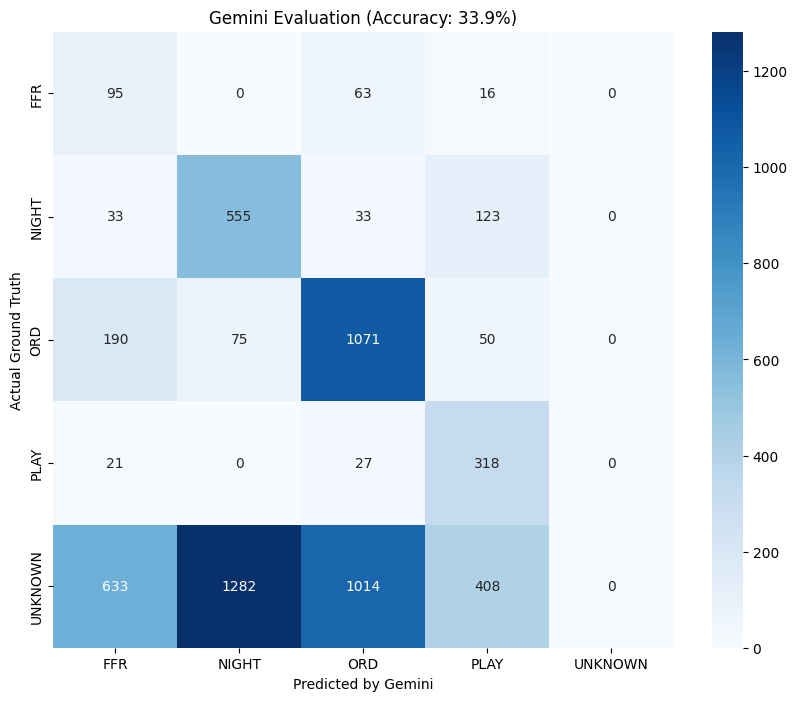

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# CONFIGURATION
RESULTS_PATH = "/content/drive/MyDrive/Dolphin_project/Project/Experiment-3/experiment3_results.csv"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/Dolphin_project/Project/vocal_annotation_all.csv"

# Output file name
OUTPUT_EXCEL = "gemini_evaluation_report.xlsx"


# LOAD DATA
print("Loading files...")
try:
    pred_df = pd.read_csv(RESULTS_PATH)
    gt_df = pd.read_csv(GROUND_TRUTH_PATH)
    print(" Files loaded successfully.")
except Exception as e:
    print(f" Error loading files: {e}")
    raise

# DATA CLEANING & MERGING
pred_df['clean_id'] = pred_df['filename'].astype(str).str.replace('.wav', '', regex=False).str.strip()
gt_df['clean_id'] = gt_df['original_audio'].astype(str).apply(os.path.basename).str.replace('.wav', '', regex=False).str.strip()

# Merge (Inner Join)
# We match the Gemini prediction with the Ground Truth label ('label_activity')
merged_df = pd.merge(pred_df, gt_df[['clean_id', 'label_activity']], on='clean_id', how='inner')

# Normalize labels (Upper case, remove spaces)
merged_df['final_verdict'] = merged_df['final_verdict'].str.strip().str.upper()
merged_df['label_activity'] = merged_df['label_activity'].str.strip().str.upper()

# Filter out UNKNOWN
merged_df = merged_df[merged_df['final_verdict'] != 'UNKNOWN']

print(f"Successfully matched {len(merged_df)} files for evaluation.")


# GENERATE EXCEL REPORT
merged_df['matched'] = merged_df['final_verdict'] == merged_df['label_activity']

# Select and rename columns as requested
report_df = merged_df[['filename', 'final_verdict', 'label_activity', 'matched', 'gemini_analysis']].copy()
report_df.columns = ['audio file name', 'gemini analysis', 'actual truth from the vocal file', 'matched', 'reason']

# Save to Excel
report_df.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n Detailed Excel report saved to: {OUTPUT_EXCEL}")

# CALCULATE METRICS
y_true = report_df['actual truth from the vocal file']
y_pred = report_df['gemini analysis']

# Overall Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\n Overall Accuracy: {acc:.2%}")

# Classification Report
print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred))

# PLOT CONFUSION MATRIX
plt.figure(figsize=(10, 8))
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted by Gemini')
plt.ylabel('Actual Ground Truth')
plt.title(f'Gemini Evaluation (Accuracy: {acc:.1%})')
plt.savefig('final_confusion_matrix.png')
print(" Confusion Matrix plot saved as 'final_confusion_matrix.png'")
plt.show()

# evalution summary

In [7]:
import pandas as pd

# USER CONFIGURATION
input_file_path = r"/content/gemini_evaluation_report.xlsx"
output_file_path = r"gemini_evaluation_summary.xlsx"

try:
    df = pd.read_excel(input_file_path)
    summary_df = df.drop_duplicates(subset=['audio file name'])
    summary_df = summary_df.rename(columns={
        'actual truth from the vocal file': 'actual value'
    })

    # Select only the specific columns you requested
    summary_df = summary_df[['audio file name', 'gemini analysis', 'actual value', 'matched', 'reason']]

    # Save to Excel
    summary_df.to_excel(output_file_path, index=False)

    print(f"Success! File saved to: {output_file_path}")

except FileNotFoundError:
    print(f"Error: The file was not found at {input_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Success! File saved to: gemini_evaluation_summary.xlsx
